# DUNL Paper Results Recreation
## BIPN 162 Final Project

By Emily McClung, Naomi Ortega, and Isabel Rodriguez

Submission
As for the cell types project, you will submit the final project on Canvas as a single pdf file. In this document, please attach your code notebook to your 5-page written report, which should include figures with captions and references (see checklist below). Please don’t forget to include your names and group number. Also, list your team member contributions, and describe to what you extent you used AI assistants to help you with coding, literature research, data analysis and writing. Remember that all members should be contributing equally across the entire project duration, and that everybody should work with the data or participate in the analysis in some form. Your document should have at least 1/2 inch margins all around, use at least 11 point font, and single (or larger) line spacing. Evaluation will primarily be based on the written report, but will also take into account materials provided in the code notebook. You only need to submit one PDF file per group.

Your code notebook should include all the code you used for all components of the project (wrangling, visualization, analysis). Before submitting, edit all text for clarity, and ensure that code is clearly commented. You can save your final notebook as an exported PDF (in Jupyter Notebook: File > Download As). Because we won’t be running the code in your notebook, it is important to make sure the PDF of your notebook has the code evaluated and all outputs present (e.g., plots) so that we can read the project as is. The main purpose of the notebook is to show that you’ve successfully run the code, but you can include additional plots or explanations of how you implemented your analysis that didn’t fit into the report. If you are not using Jupyter Notebooks (perhaps because the code you downloaded for option #2 came in a different format) you can submit a pdf of your annotated Python code instead, but the same considerations about clarity and explanatory comments apply (especially for the parts of any downloaded code that you modified, which should be clearly indicated).

 



Final Project Report Checklist
Please use the following checklist and the rubric below to help guide your thinking.

## 1. Abstract

Overview: Write a clear 3-4 sentence summary of what you did and why it's interesting/valuable.
Research Question: Include your specific data science question and make sure what you’re measuring (variables) to answer your question is clear

## 2. Introduction & Background (~400-500 words)

Include explanation of what work has been done previously, with citations or links to previous work
Include an explanation of data set(s) used (i.e., how the data was collected, features/variables included, information in data set). Be clear about why you're mining this specific set of data.

For implementing/replicating a new method (option #2), describe the paper you chose and the method you will be studying, as well as the specific scientific question addressed by the original work and how that can be extended to the new data set you will use.

## 3. Data Analysis 

Data Wrangling
* Pull your data into Python and explain steps taken to isolate the data you need. Be sure to include any preprocessing.
* Include a clear explanation of the number of observations in the data and which observations (if any) are missing, and how this was handled.
  
Data Visualization

* Include at least six visualizations (figure panels) in total, both exploratory (looking at the raw data) and hypothesis-driven.
* Choose appropriate plot types (ideally not all the same) and clearly label all axes on plots.
* Interpret each visualization & corresponding analysis from a scientific perspective.

Data Analysis & Results
* Analysis pipeline described step by step.
* Appropriate statistical analysis performed for your question & data (including statistical tests where appropriate).
* 
If Option #1:----
* If Option #2: Demonstrate that you understand and have accurately implemented the method. Show that you can reproduce results from your chosen paper and obtain results by applying the method to a new data set.
Output of analysis interpreted appropriately.

In [18]:
#import necessary packages
import numpy
import torch
import sklearn
import h5py
import configmypy
import matplotlib.pyplot as plt

In [1]:
#CLone the DUNL algorithm GitHub Repository
!git clone https://github.com/btolooshams/dunl-compneuro.git

fatal: destination path 'dunl-compneuro' already exists and is not an empty directory.


In [ ]:
#Import the DUNL code
import sys
sys.path.append("dunl-compneuro")
import dunl

In [2]:
!ls dunl-compneuro/dunl

__pycache__	     preprocess_scripts
boardfunc.py	     train_fiber_loop_acrossneurons.py
datasetloader.py     train_independentkernels_acrossneurons.py
lossfunc.py	     train_sharekernels_acrossneurons.py
model.py	     train_sharekernels_acrossneurons_groupneuralfirings.py
postprocess_scripts  utils.py


## Reproducing DUNL paper results
* recreate some main claims from the paper
* recreate 1 visualization

Recreate this from the paper
DUNL uncovers salience and value signals from single dopamine neurons

We recreate Figure 2 from their dopamine spiking experiment.
We use their data from the experiment that is available here: https://data.mendeley.com/datasets/rzfyr2886h/1 


In [ ]:
!unzip dopamine-spiking-eshel-uchida.zip

In [5]:
!ls dopamine-spiking-eshel-uchida

02_09_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
02_11_TT2_4_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_05_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_05_TT6_3_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_05_TT8_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_07_TT8_2_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_15_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
03_15_TT6_2_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
10_12_TT8_

-- 
dont have their data for this
https://www.sciencedirect.com/science/article/pii/S0896627325001199?via%3Dihub&__cf_chl_tk=ciAiiTtNplR9ZLzw.GfrPtxgB13Vrw5GkGYNLmeqrZE-1772596451-1.0.1.1-paMjoHZJrF.KH5WIUydvHj4PlmuVP5ILOuwknDxMOzU#mmc1 

DUNL Paper:
"Second, we analyzed multi-fiber photometry recordings from a single session of a behaving mouse exposed to multiple events and objects in an unstructured experiment where events were not pre-timed (Figure 5G). These recordings captured calcium concentration changes in dopamine axons across different striatal regions, each monitored by a separate optical fiber. DUNL was used to identify a single kernel for each fiber over the entire 90-min session (Figure 5H)." 

In [6]:
#load one part of the data to look at it
data = torch.load("dopamine-spiking-eshel-uchida/02_09_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt")
print(data.keys())

dict_keys(['raster', 'time_org_resolution', 'time_bin_resolution', 'y', 'x', 'a', 'type'])


The data are already in training format ready to be used with DUNL.
Understanding the keys in the data:
Raster =
y = 
x = 
a = 
type = 

In [14]:
#Move data into folder the algorithm expects
!mkdir -p dunl-compneuro/data
!mv dopamine-spiking-eshel-uchida dunl-compneuro/data/

Changes made to config:
1. In `config/dopamine_spiking_eshel_uchida_code122_kernel011_config.yaml/`
changed **from** `data_folder:  "../data/dopamine-spiking-eshel-uchida"`
**to** `data_folder: "dunl-compneuro/data/dopamine-spiking-eshel-uchida"`

2. In `dunl/train_sharekernels_acrossneurons.py` inside `init_params()`
 **commented out** `default="./dopamine_calcium_saramatias_uchida_config.yaml"`
and **uncommented** `default="./dopamine_spiking_eshel_uchida_code122_kernel011_config.yaml"` because we are running the dopamine spiking experiment on the dopamine spiking data, but this code contains configurations for the other experiments from their paper too. On the Seiler 000971 fiber photometry data we will use the calcium configuration.




In [ ]:
##Run DUNL training.

In [18]:
!python dunl-compneuro/dunl/train_sharekernels_acrossneurons.py

Train DUNL on neural data.
device is cuda:0
init parameters.
Exp: dopaminespiking_25msbin_kernellength24_kernelnum3_code122_kernel011
create board.
create dataset and dataloader.
There 39 dataset in the folder.
dunl-compneuro/data/dopamine-spiking-eshel-uchida/10_26_TT6_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/D_04-29_16-11-32_TT6_4_Common_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/02_13_TT2_1_CommonFormat_verified_25msbinres_general_format_processed_kernellength24_kernelnum3_trainready.pt
x is shared among neurons. It is a function of trials, and number of kernels!
dunl-compneuro/data/dopamine-spiking-eshel-uchida/O_05-06_14-45-15_TT8_2_Common

Training DUNL is complete. Now we will inspect the results.

In [5]:
import sys
sys.path.append("dunl-compneuro/dunl")

In [6]:
model = torch.load(
    "dunl-compneuro/results/dopaminespiking_25msbin_kernellength24_kernelnum3_code122_kernel011_2026_03_04_17_44_00/model/model_final.pt"
)

In [8]:
print(model)
model.state_dict().keys()

DUNL1D(
  (relu): ReLU()
  (sigmoid): Sigmoid()
)


odict_keys(['H', 'unrolling_alpha', 'code_sparse_regularization', 'code_pos_sided', 'code_neg_sided'])

H contains the learned kernels. We inspect the kernel tensor:

In [17]:
H = model.state_dict()['H']
print(H.shape) #There are 3 kernels, 1 channel, and 24 time bins. The 3 kernels matches the 3 kernels found in the paper.

torch.Size([3, 1, 24])


In [16]:
H_np = H.detach().cpu().numpy() #convert the kernels from a tensor to a numpy array

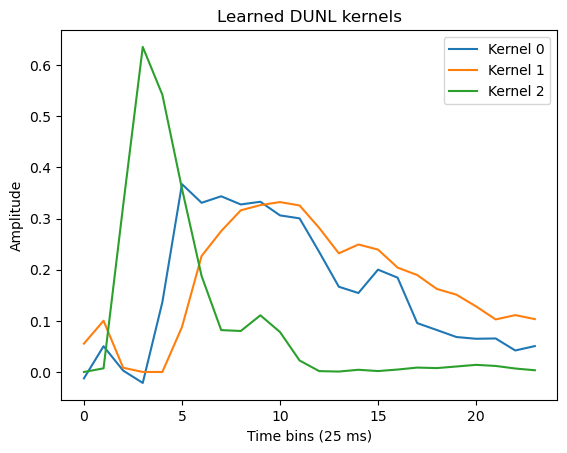

In [19]:
for i in range(H_np.shape[0]):
    plt.plot(H_np[i,0], label=f"Kernel {i}")

plt.legend()
plt.title("Learned DUNL kernels")
plt.xlabel("Time bins (25 ms)")
plt.ylabel("Amplitude")
plt.show()

In [20]:
H_np.min(), H_np.max()

(-0.021408133, 0.6355166)

In [9]:
dir(model)

['H',
 'T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules',
 '_named_members',
 '_non_persistent_buff

## Applying DUNL to another dataset

We will now apply the DUNL analysis method to a dataset of Fiber Photometry and Optogenetics recordings.

In [ ]:
##unzipping
!unzip 000971_Data/sub-61-207.zip -d sub-61-207

In [ ]:
#Loading data
from pynwb import NWBHDF5IO

file_path = "Data_Seiler.zip"  # adjust path

io = NWBHDF5IO(file_path, mode='r')
nwbfile = io.read()

In [ ]:
from stream_nwbfile import stream_nwbfile
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from pathlib import Path

##Load the Fiber Photometry Data from one subject
data_root = Path('FP_Data')
FP_files = list(data_root.rglob('*.nwb'))
print("Fiber Photometry Data contains {} files".format(len(FP_files)))

## Load the Optogenetics Data from one subject
data_root = Path('OPT_Data')
OPT_files = list(data_root.rglob('*.nwb'))
print("Optogenetics Data contains {} files".format(len(OPT_files)))